# Anterior

Escalamos los datos para poder realizar el análisis con DBSCAN

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_dqi_final)


In [ ]:
df_dqi_final_scaled = pd.DataFrame(scaled_data, columns=df_dqi_final.columns)

In [ ]:
# Visualizamos los primeros registros
df_dqi_final_scaled.head()

,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,...,dqi_adequacy_grains,dqi_adequacy_fiber,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador
0,-0.506048,-0.220004,-0.56279,-0.580748,-0.600842,-0.532675,0.743445,0.119618,-0.225977,0.479483,...,-0.664438,0.498523,0.328084,1.238602,-0.556848,0.691465,0.793164,0.636326,0.828558,-0.767985
1,-0.506048,-0.220004,-0.56279,0.937766,-0.600842,-0.532675,-1.634088,0.119618,-0.819281,0.479483,...,-0.664438,1.111351,0.328084,1.238602,0.027476,0.691465,0.910765,0.480928,-1.052116,-0.448777
2,-0.506048,-0.220004,-0.56279,0.937766,-0.600842,-0.532675,-1.634088,0.119618,-0.819281,1.194227,...,-0.664438,1.111351,0.328084,0.560876,0.027476,0.691465,0.793164,0.636326,1.656054,-0.780565
3,-0.506048,-0.220004,-0.56279,-0.580748,-0.600842,-0.532675,-1.634088,0.119618,-1.412586,-0.235260,...,-0.664438,-0.114305,0.328084,-0.116849,-0.556848,-1.149236,-0.500451,-0.917649,-0.525528,-0.628697
4,-0.506048,-0.220004,-0.56279,-0.580748,-0.600842,-0.532675,-1.634088,0.119618,-1.412586,1.194227,...,1.236511,1.111351,0.328084,1.238602,1.196123,0.691465,1.498772,0.869422,1.505600,-0.714937


Este código aplica el modelo DBSCAN a todas las combinaciones posibles de 3 columnas numéricas del DataFrame df_dqi_final_scaled, ejecutando las combinaciones en paralelo para mejorar la eficiencia. Los resultados incluyen el número de clusters, el número de puntos de ruido y las etiquetas de los clusters para cada combinación de columnas, y se almacenan en un DataFrame para su análisis.

In [ ]:
from joblib import Parallel, delayed
from sklearn.cluster import DBSCAN
import pandas as pd
from itertools import combinations

# Lista de columnas numéricas
columns = df_dqi_final_scaled.columns

# Definir la función de DBSCAN para una combinación
def run_dbscan(combo):
    df_subset = df_dqi_final_scaled[list(combo)]
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    dbscan.fit(df_subset)
    labels = dbscan.labels_
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    return {'columns': combo, 'n_clusters': n_clusters_, 'n_noise': n_noise_, 'labels': labels}

# Ejecutar en paralelo usando joblib
all_results = Parallel(n_jobs=-1)(delayed(run_dbscan)(combo) for combo in combinations(columns, 3))

# Convertir a DataFrame para visualizar resultados
results_df = pd.DataFrame(all_results)
print(results_df)


                                                columns  n_clusters  n_noise  \
0     (macronutrients_dqi, fatty_acids_dqi, balance_...           5        7   
1     (macronutrients_dqi, fatty_acids_dqi, empty_ca...          13       12   
2     (macronutrients_dqi, fatty_acids_dqi, total_fa...           8       18   
3     (macronutrients_dqi, fatty_acids_dqi, saturate...          11       15   
4     (macronutrients_dqi, fatty_acids_dqi, choleste...          11       16   
...                                                 ...         ...      ...   
2019         (dqi_adequacy_vitamin_c, edad, ponderador)           9       66   
2020                    (dqi_adecuacy, dqi_total, edad)           2       11   
2021              (dqi_adecuacy, dqi_total, ponderador)           3       38   
2022                   (dqi_adecuacy, edad, ponderador)           2       65   
2023                      (dqi_total, edad, ponderador)           2       77   

                                       

En lo siguiente se grafican los resultados obtenidos del análisis de DBSCAN mostrando el top 10 de número de clusters encontrados dentro del dataset con todas las combinaciones posibles en grupos de 3 de las columnas. 

In [ ]:
results_df.head()

,columns,n_clusters,n_noise,labels
0,"(macronutrients_dqi, fatty_acids_dqi, balance_...",5,7,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 1,..."
1,"(macronutrients_dqi, fatty_acids_dqi, empty_ca...",13,12,"[0, 1, 1, 0, 0, 0, 0, 0, 2, 2, 0, -1, 0, 0, 3,..."
2,"(macronutrients_dqi, fatty_acids_dqi, total_fa...",8,18,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, -1..."
3,"(macronutrients_dqi, fatty_acids_dqi, saturate...",11,15,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, -1, 0, 0, -1..."
4,"(macronutrients_dqi, fatty_acids_dqi, choleste...",11,16,"[0, 1, 1, 1, 1, 2, 0, 2, 1, 0, 2, -1, 0, 1, 3,..."


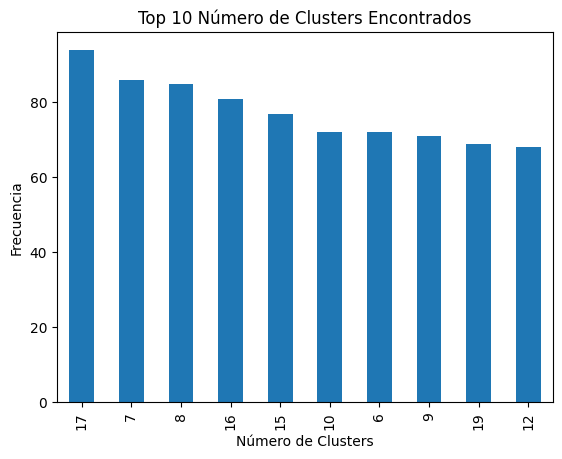

In [ ]:
# Visualizar los resultados de results_df para combinaciones de 3 columnas
top_10_clusters = results_df['n_clusters'].value_counts().head(10)
top_10_clusters.plot(kind='bar', title='Top 10 Número de Clusters Encontrados')
plt.xlabel('Número de Clusters')
plt.ylabel('Frecuencia')
plt.show()

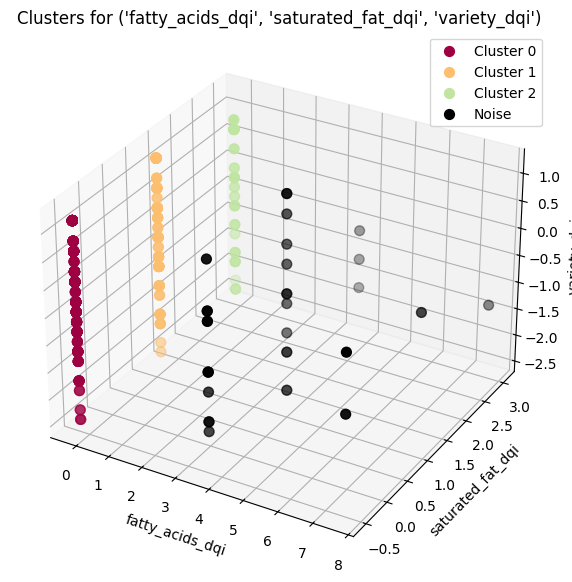

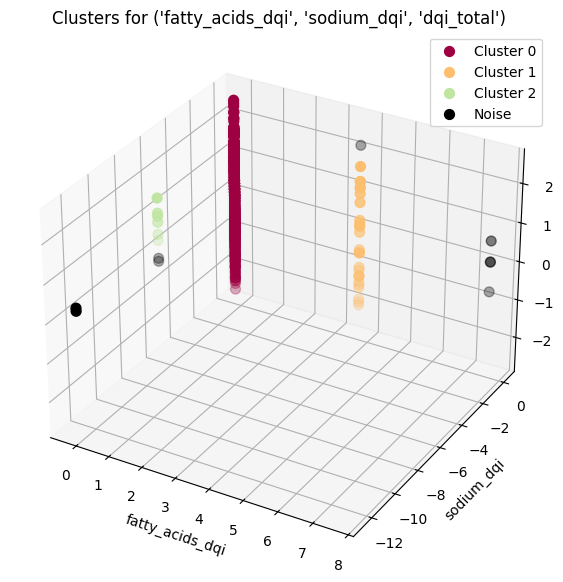

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Filtrar results_df para obtener los primeros 3 registros con 10 clusters
selected_results = results_df[results_df['n_clusters'] == 3].head(2)

# Graficar cada conjunto de columnas en 3D
for _, row in selected_results.iterrows():
    combo = row['columns']  # Obtener la combinación de columnas
    labels = row['labels']  # Etiquetas de los clusters
    df_subset = df_dqi_final_scaled[list(combo)]  # Subset del dataset original escalado

    # Crear figura 3D
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Negro para ruido
            col = [0, 0, 0, 1]
        class_member_mask = (np.array(labels) == k)
        xyz = df_subset[class_member_mask]

        ax.scatter(xyz.iloc[:, 0], xyz.iloc[:, 1], xyz.iloc[:, 2], color=tuple(col), label=f'Cluster {k}' if k != -1 else 'Noise', s=50)

    # Etiquetas de los ejes
    ax.set_xlabel(combo[0])
    ax.set_ylabel(combo[1])
    ax.set_zlabel(combo[2])
    
    # Leyenda y título
    ax.legend()
    ax.set_title(f"Clusters for {combo}")

    # Mostrar el gráfico
    plt.show()


Análisis bivariado con dfi_total

In [ ]:
from joblib import Parallel, delayed
from sklearn.cluster import DBSCAN
import pandas as pd
from itertools import combinations

# Lista de columnas numéricas excluyendo dqi_total
columns = [col for col in df_dqi_final_scaled.columns if col != 'dqi_total']

# Definir la función de DBSCAN para una combinación con dqi_total como referencia
def run_dbscan(combo):
    # Agregar 'dqi_total' a cada combinación de 2 columnas
    df_subset = df_dqi_final_scaled[['dqi_total'] + list(combo)]
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    dbscan.fit(df_subset)
    labels = dbscan.labels_
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    return {'columns': ('dqi_total',) + combo, 'n_clusters': n_clusters_, 'n_noise': n_noise_, 'labels': labels}

# Ejecutar en paralelo usando joblib
all_results = Parallel(n_jobs=-1)(delayed(run_dbscan)(combo) for combo in combinations(columns, 2))

# Convertir a DataFrame para visualizar resultados
results_df_2cols = pd.DataFrame(all_results)
results_df_2cols.head()


,columns,n_clusters,n_noise,labels
0,"(dqi_total, macronutrients_dqi, fatty_acids_dqi)",8,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 1,..."
1,"(dqi_total, macronutrients_dqi, balance_dqi)",8,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 1,..."
2,"(dqi_total, macronutrients_dqi, empty_calories...",9,29,"[0, 1, 1, 0, 0, 0, 0, 0, 2, 2, 0, 3, 0, 0, 4, ..."
3,"(dqi_total, macronutrients_dqi, total_fat_dqi)",10,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, -1,..."
4,"(dqi_total, macronutrients_dqi, saturated_fat_...",12,26,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, -1,..."


<Axes: title={'center': 'Top 10 Número de Clusters Encontrados'}, xlabel='n_clusters'>

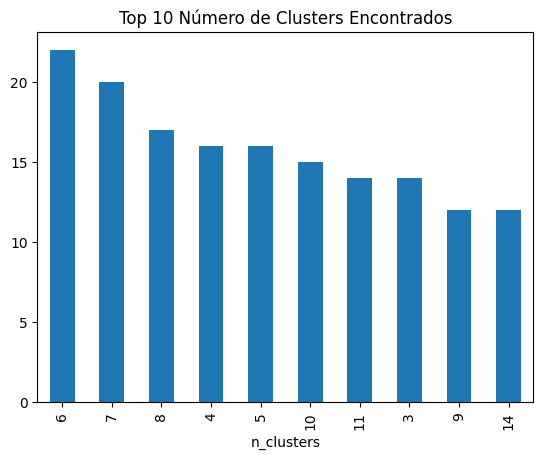

In [ ]:
# resultados de results_df_2cols
top_10_clusters = results_df_2cols['n_clusters'].value_counts().head(10)
top_10_clusters.plot(kind='bar', title='Top 10 Número de Clusters Encontrados')